# Logistic regression and gradient descent

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/classification/02-logistic-regression-gradient-descent.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In the likelihood notebook, we selected the probability that best
explained a set of red/blue ticket draws. Here, we use the same
maximum-likelihood idea to fit a logistic-regression model for
gas-turbine operating observations.

In the data, each row records one operating observation. Our target is the
course-defined high-CO label: it is 1 when CO is at least 2 mg/m³ and
0 otherwise. We will use turbine inlet temperature (TIT) as one
feature and implement gradient descent ourselves.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

## 1. Set up the turbine classification task

The same course dataset supported our regression examples. This time,
the measured CO value has already been converted into a binary label,
so we can focus on the probability model rather than on constructing
the label.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])

# In Google Colab, download the small course dataset if it is not already present.
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
model_data = data[["TIT", "CO", "high_co"]].dropna().copy()

print(f"Usable operating observations: {len(model_data):,}")
print(f"High-CO observations: {model_data['high_co'].sum():,} ({model_data['high_co'].mean():.1%})")
model_data.head()

Usable operating observations: 36,733
High-CO observations: 14,270 (38.8%)


,TIT,CO,high_co
0,1086.2,0.32663,0
1,1086.1,0.44784,0
2,1086.5,0.45144,0
3,1086.5,0.23107,0
4,1085.9,0.26747,0


A logistic model does not try to draw a straight line through 0/1
labels. Instead, it estimates the chance of a high-CO observation.
The small vertical jitter below is only for visibility; the labels
themselves remain 0 or 1.

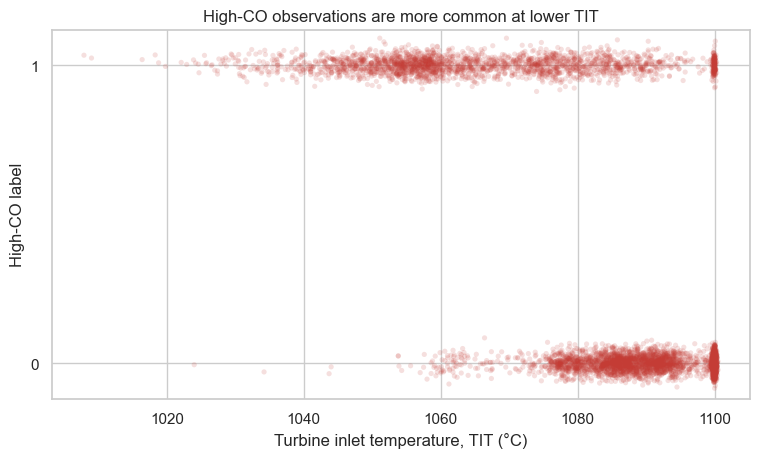

In [3]:
plot_data = model_data.sample(n=min(6_000, len(model_data)), random_state=4520)
rng = np.random.default_rng(4520)
label_jitter = plot_data["high_co"] + rng.normal(0, 0.025, len(plot_data))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(
    plot_data["TIT"],
    label_jitter,
    s=14,
    alpha=0.16,
    color="#c43c35",
    edgecolor="none",
)
ax.set(
    xlabel="Turbine inlet temperature, TIT (°C)",
    ylabel="High-CO label",
    yticks=[0, 1],
    ylim=(-0.12, 1.12),
    title="High-CO observations are more common at lower TIT",
)
plt.show()

## 2. A logistic probability model

Let $y_i$ be the high-CO label for observation $i$. We first
standardize TIT, then map a linear score to a probability with the
sigmoid function:

$$
\tilde{x}_i = \frac{\mathrm{TIT}_i-\overline{\mathrm{TIT}}}{s_{\mathrm{TIT}}},
\qquad
z_i=\beta_0+\beta_1\tilde{x}_i,
\qquad
p_i=P(y_i=1\mid \tilde{x}_i)=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.
$$

Standardizing TIT is not a different model. It is a convenient
re-expression of the same feature: $\beta_1$ now describes a
one-standard-deviation change in TIT, and a single learning rate can
update both coefficients sensibly.

In [4]:
tit_mean = model_data["TIT"].mean()
tit_std = model_data["TIT"].std(ddof=0)
model_data["tit_standardized"] = (model_data["TIT"] - tit_mean) / tit_std

# The first column of X supplies the intercept; the second is standardized TIT.
X = np.column_stack([
    np.ones(len(model_data)),
    model_data["tit_standardized"].to_numpy(),
])
y = model_data["high_co"].to_numpy(dtype=float)

def sigmoid(z: float | np.ndarray) -> float | np.ndarray:
    """Map linear score(s) to probability values.

    Args:
        z: A scalar or NumPy array of linear scores.

    Returns:
        The corresponding probability or array of probabilities in [0, 1].
    """
    return 1 / (1 + np.exp(-z))

print(f"Mean TIT: {tit_mean:.2f} °C")
print(f"Standard deviation of TIT: {tit_std:.2f} °C")
print(f"Design-matrix shape: {X.shape}")

Mean TIT: 1081.43 °C
Standard deviation of TIT: 17.54 °C
Design-matrix shape: (36733, 2)


## 3. Turn likelihood into a loss function

For independent binary observations, maximizing the likelihood is
equivalent to minimizing the average negative log-likelihood, also
called **binary cross-entropy**:

$$
\mathcal{L}_{\mathrm{BCE}}(\boldsymbol{\beta})
=-\frac{1}{n}\sum_{i=1}^{n}
\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right].
$$

Smaller values mean that the model assigns higher probability to the
labels we actually observed. To minimize this loss, we also need its
gradient with respect to the coefficient vector:

$$
\mathbf{p}=\sigma(\mathbf{X}\boldsymbol{\beta}),
\qquad
\nabla\mathcal{L}_{\mathrm{BCE}}(\boldsymbol{\beta})
=\frac{1}{n}\mathbf{X}^{\mathsf{T}}(\mathbf{p}-\mathbf{y}).
$$

Here, $\mathbf{X}$ is the design matrix, $\mathbf{p}$ contains the
predicted probabilities, and $\mathbf{y}$ contains the observed 0/1
labels. The vector $\mathbf{p}-\mathbf{y}$ measures each prediction's
error; multiplying by $\mathbf{X}^{\mathsf{T}}$ combines those errors
into one update direction for the two coefficients.

The `loss_and_gradient` function below follows that sequence:

1. Compute one linear score for each observation.
2. Transform the scores into predicted probabilities with the sigmoid.
3. Compute and average the per-observation binary cross-entropy losses.
4. Combine the probability errors into the gradient above.

The code below follows the displayed expression directly. It clips
probabilities only to prevent taking the logarithm of 0 if floating-point
roundoff produces an extreme value of exactly 0 or 1.

In [5]:
def loss_and_gradient(
    beta: np.ndarray, X: np.ndarray, y: np.ndarray
) -> tuple[float, np.ndarray]:
    """Compute binary cross-entropy and its gradient.

    Args:
        beta: Current intercept and standardized-TIT slope, shape (2,).
        X: Design matrix with intercept and standardized-TIT columns.
        y: Observed high-CO labels, encoded as zeros and ones.

    Returns:
        A pair containing the average binary cross-entropy and its
        gradient with respect to `beta`.
    """
    # One linear score and one predicted probability per observation.
    scores = X @ beta
    probabilities = sigmoid(scores)

    # Keep logarithms defined if floating-point roundoff produces 0 or 1.
    safe_probabilities = np.clip(probabilities, 1e-12, 1 - 1e-12)
    per_observation_loss = -(
        y * np.log(safe_probabilities)
        + (1 - y) * np.log(1 - safe_probabilities)
    )
    loss = np.mean(per_observation_loss)

    # Weight probability errors by the feature values, then average them.
    probability_errors = probabilities - y
    gradient = X.T @ probability_errors / len(y)
    return float(loss), gradient

initial_beta = np.array([0.0, 0.0])
initial_loss, initial_gradient = loss_and_gradient(initial_beta, X, y)

print("At β₀ = β₁ = 0, every predicted probability is 0.5.")
print(f"Initial BCE: {initial_loss:.4f}")
print(f"Gradient: {initial_gradient}")

At β₀ = β₁ = 0, every predicted probability is 0.5.
Initial BCE: 0.6931
Gradient: [0.11152098 0.31981404]


## 4. One gradient-descent update

The gradient introduced above points in the direction of greatest local
increase in the loss. To decrease the loss, we step in the opposite
direction:

$$
\boldsymbol{\beta}^{(t+1)}
=\boldsymbol{\beta}^{(t)}-\eta\nabla\mathcal{L}_{\mathrm{BCE}}
\left(\boldsymbol{\beta}^{(t)}\right).
$$

Here, $\eta$ is the learning rate. It controls how far one update
travels. We begin at $(0,0)$ and use $\eta=0.75$.

In [6]:
learning_rate = 0.75
one_step_beta = initial_beta - learning_rate * initial_gradient
one_step_loss, _ = loss_and_gradient(one_step_beta, X, y)

print(f"Start: β = {initial_beta}, BCE = {initial_loss:.4f}")
print(f"After one step: β = {one_step_beta.round(3)}, BCE = {one_step_loss:.4f}")

Start: β = [0. 0.], BCE = 0.6931
After one step: β = [-0.084 -0.24 ], BCE = 0.6151


## 5. Repeat the updates

A complete gradient-descent fit repeats the same calculation many
times. The history records the coefficient values and loss after every
iteration, including the starting point.

For a fixed learning rate, the algorithm is:

1. Start with an initial coefficient vector $\boldsymbol{\beta}^{(0)}$.
2. Compute the predicted probabilities and the loss gradient.
3. Move one step opposite the gradient.
4. Repeat until the loss and coefficients no longer change much.

In [7]:
def gradient_descent(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.75,
    n_steps: int = 100,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Fit logistic-regression coefficients with gradient descent.

    Args:
        X: Design matrix with intercept and standardized-TIT columns.
        y: Observed high-CO labels, encoded as zeros and ones.
        learning_rate: Size of each update opposite the gradient.
        n_steps: Number of coefficient updates to perform.

    Returns:
        A pair containing the final coefficient vector and a table with
        the coefficient values and BCE at every iteration.
    """
    beta = np.zeros(X.shape[1])
    history = []

    for iteration in range(n_steps + 1):
        loss, gradient = loss_and_gradient(beta, X, y)
        history.append({
            "iteration": iteration,
            "beta_0": beta[0],
            "beta_1": beta[1],
            "bce": loss,
        })

        if iteration < n_steps:
            beta = beta - learning_rate * gradient

    return beta, pd.DataFrame(history)

beta_hat, history = gradient_descent(X, y, learning_rate=learning_rate, n_steps=100)
history.iloc[[0, 1, 2, 5, 10, 25, 50, 100]].round(4)

,iteration,beta_0,beta_1,bce
0,0,0.0000,0.0000,0.6931
1,1,-0.0836,-0.2399,0.6151
2,2,-0.1516,-0.4353,0.5632
5,5,-0.2904,-0.8464,0.4845
10,10,-0.4055,-1.2376,0.4415
25,25,-0.4978,-1.7219,0.4182
50,50,-0.5102,-1.9517,0.4150
100,100,-0.5082,-2.0307,0.4147


With two coefficients, we can view the loss as a surface. The contour
plot below is a top-down view: lighter contours have lower binary
cross-entropy. The red path shows the successive gradient-descent
estimates.

/var/folders/ck/6xgx96j15vd6tcwzl68twbpc0000gn/T/ipykernel_43232/43750391.py:33: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ck/6xgx96j15vd6tcwzl68twbpc0000gn/T/ipykernel_43232/43750391.py:33: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/changyaochen/Projects/MECE4520/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/changyaochen/Projects/MECE4520/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


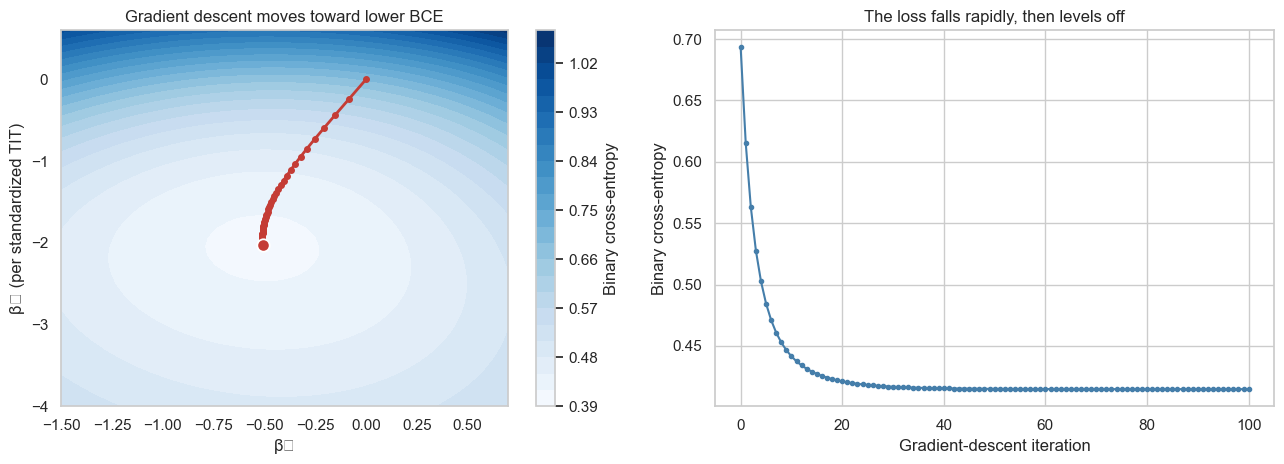

In [8]:
beta_0_values = np.linspace(-1.5, 0.7, 41)
beta_1_values = np.linspace(-4.0, 0.6, 41)
loss_surface = np.empty((len(beta_1_values), len(beta_0_values)))

for row, beta_1 in enumerate(beta_1_values):
    for column, beta_0 in enumerate(beta_0_values):
        loss_surface[row, column], _ = loss_and_gradient(
            np.array([beta_0, beta_1]), X, y
        )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

contours = axes[0].contourf(
    beta_0_values, beta_1_values, loss_surface, levels=22, cmap="Blues"
)
axes[0].plot(history["beta_0"], history["beta_1"], color="#c43c35", linewidth=2)
axes[0].scatter(history["beta_0"], history["beta_1"], color="#c43c35", s=16, zorder=3)
axes[0].scatter(beta_hat[0], beta_hat[1], color="#c43c35", edgecolor="white", linewidth=1.3, s=80, zorder=4)
axes[0].set(
    xlabel="β₀",
    ylabel="β₁ (per standardized TIT)",
    title="Gradient descent moves toward lower BCE",
)
fig.colorbar(contours, ax=axes[0], label="Binary cross-entropy")

axes[1].plot(history["iteration"], history["bce"], color="#457eaa", marker="o", markersize=3)
axes[1].set(
    xlabel="Gradient-descent iteration",
    ylabel="Binary cross-entropy",
    title="The loss falls rapidly, then levels off",
)

plt.tight_layout()
plt.show()

## 6. Return to the raw TIT scale

The optimization used standardized TIT, but we can draw the fitted
probability curve against the original TIT values. If

$$
p_i=\sigma(\beta_0+\beta_1\tilde{x}_i),
$$

then the equivalent raw-TIT coefficients are

$$
b_1=\frac{\beta_1}{s_{\mathrm{TIT}}},
\qquad
b_0=\beta_0-\frac{\beta_1\overline{\mathrm{TIT}}}{s_{\mathrm{TIT}}}.
$$

The fitted curve gives a probability, not a promise that each
individual 0/1 observation will match the curve.

Standardized-scale fit: β₀ = -0.508, β₁ = -2.031
Raw-TIT fit: log-odds = 124.725 + (-0.11580) × TIT


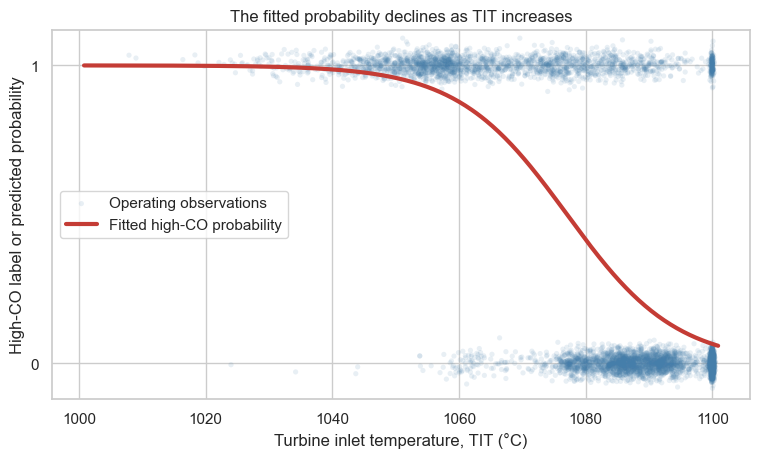

In [9]:
raw_slope = beta_hat[1] / tit_std
raw_intercept = beta_hat[0] - beta_hat[1] * tit_mean / tit_std

print(f"Standardized-scale fit: β₀ = {beta_hat[0]:.3f}, β₁ = {beta_hat[1]:.3f}")
print(f"Raw-TIT fit: log-odds = {raw_intercept:.3f} + ({raw_slope:.5f}) × TIT")

tit_grid = np.linspace(model_data["TIT"].min(), model_data["TIT"].max(), 400)
standardized_grid = (tit_grid - tit_mean) / tit_std
probability_grid = sigmoid(beta_hat[0] + beta_hat[1] * standardized_grid)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(
    plot_data["TIT"],
    label_jitter,
    s=14,
    alpha=0.12,
    color="#457eaa",
    edgecolor="none",
    label="Operating observations",
)
ax.plot(tit_grid, probability_grid, color="#c43c35", linewidth=3, label="Fitted high-CO probability")
ax.set(
    xlabel="Turbine inlet temperature, TIT (°C)",
    ylabel="High-CO label or predicted probability",
    yticks=[0, 1],
    ylim=(-0.12, 1.12),
    title="The fitted probability declines as TIT increases",
)
ax.legend()
plt.show()

## Try it

Change the learning rate in the starter cell below. A smaller value
makes slower progress; a much larger value can overshoot the
low-loss region. Compare the final loss with the one above.

In [10]:
# Try it: fit again with a smaller learning rate.
# _, slower_history = gradient_descent(X, y, learning_rate=0.15, n_steps=100)
# slower_history.tail()

[← Return to Classification](index.qmd)